# Seizure Prediction -- Complete ML Study

A self-contained notebook for epileptic seizure prediction using Logistic Regression across three EEG datasets.

## Section 0 -- Imports and Global Configuration

In [1]:
import tempfile
import shutil
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.signal import welch

from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                      cross_validate, validation_curve,
                                      learning_curve, train_test_split)
from sklearn.metrics import (average_precision_score, f1_score, accuracy_score,
                               precision_recall_curve, confusion_matrix,
                               classification_report)

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')

# Global constants
SEED         = 42
DATASET_DIR  = 'dataset'
FIGURES_DIR  = os.path.join('outputs', 'figures')
RESULTS_DIR  = os.path.join('outputs', 'results')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

np.random.seed(SEED)

DATASET_PATHS = {
    'UCI_EEG':   os.path.join(DATASET_DIR, 'EpilepticSeizureRecognition.csv'),
    'BEED':      os.path.join(DATASET_DIR, 'beed_dataset.csv'),
    'Brainwave': os.path.join(DATASET_DIR, 'eeg_brainwave.csv'),
}

def save_fig(filename):
    path = os.path.join(FIGURES_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {path}')

# Create a temporary directory for pipeline caching
cachedir = tempfile.mkdtemp()
print(f'Created temporary pipeline cache: {cachedir}')


Created temporary pipeline cache: C:\Users\Admin\AppData\Local\Temp\tmpssoyxfs7


## Section 1 -- Dataset Loading and EDA

### 1.1 -- Dataset loader

In [2]:
def load_dataset(name, path):
    """
    Load CSV, remap labels to binary (1=seizure, 0=non-seizure).
    Returns (X, y, df) or (None, None, None) on failure.
    """
    try:
        df = pd.read_csv(path, comment='#')

        if name == 'UCI_EEG':
            # Drop unnamed index column if present
            df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
            # Target column is 'y': value 1 = seizure, 2/3/4/5 = non-seizure
            y = (df['y'] == 1).astype(int)
            X = df.drop(columns=['y'])

        elif name == 'BEED':
            # Label column 'y'; any non-zero = seizure
            label_col = 'y'
            y = (df[label_col] != 0).astype(int)
            X = df.drop(columns=[label_col])

        elif name == 'Brainwave':
            # Last column is 'label' (string); remap to binary
            label_col = df.columns[-1]
            y = (df[label_col] == 'NEGATIVE').astype(int)
            X = df.drop(columns=[label_col])

        # Drop any remaining non-numeric columns
        X = X.select_dtypes(include=[np.number])
        # Fill missing values with column median
        X = X.fillna(X.median())

        print(f'[{name}] Loaded  shape={X.shape}  seizure%={y.mean()*100:.2f}%  '
              f'missing_after_fill={X.isnull().sum().sum()}')
        return X, y, df

    except FileNotFoundError:
        print(f"[{name}] WARNING: file not found at '{path}'. Skipping.")
        return None, None, None
    except Exception as e:
        print(f'[{name}] ERROR: {e}. Skipping.')
        return None, None, None

### 1.2 -- Load all datasets

In [3]:
data = {}
for name, path in DATASET_PATHS.items():
    X, y, df = load_dataset(name, path)
    if X is not None:
        data[name] = {'X': X, 'y': y}

print(f'\nLoaded datasets: {list(data.keys())}')

[UCI_EEG] Loaded  shape=(11500, 178)  seizure%=20.00%  missing_after_fill=0
[BEED] Loaded  shape=(8000, 16)  seizure%=75.00%  missing_after_fill=0
[Brainwave] Loaded  shape=(2131, 2548)  seizure%=33.18%  missing_after_fill=0

Loaded datasets: ['UCI_EEG', 'BEED', 'Brainwave']


### 1.3 -- Summary table

In [4]:
summary_rows = []
for name, d in data.items():
    summary_rows.append({
        'Dataset':       name,
        'Samples':       d['X'].shape[0],
        'Features':      d['X'].shape[1],
        'Seizure_%':     round(d['y'].mean() * 100, 2),
        'Non_Seizure_%': round((1 - d['y'].mean()) * 100, 2),
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(os.path.join(RESULTS_DIR, 'dataset_summary.csv'), index=False)

,Dataset,Samples,Features,Seizure_%,Non_Seizure_%
0,UCI_EEG,11500,178,20.00,80.00
1,BEED,8000,16,75.00,25.00
2,Brainwave,2131,2548,33.18,66.82


### 1.4 -- Class distribution bar chart (fig1)

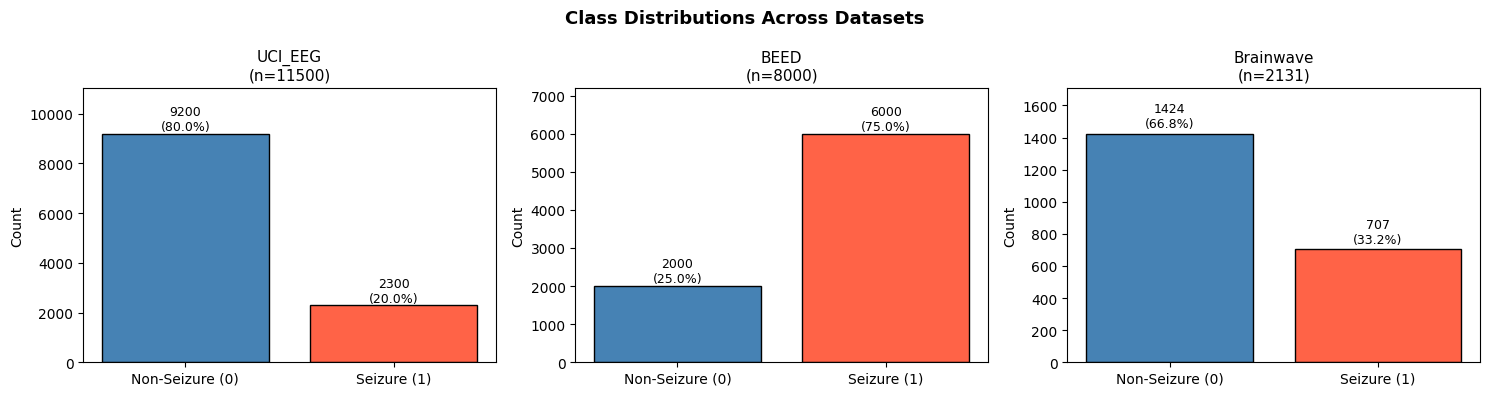

Saved -> outputs\figures\fig1_class_distributions.png


In [5]:
fig, axes = plt.subplots(1, len(data), figsize=(5 * len(data), 4))
if len(data) == 1:
    axes = [axes]

for ax, (name, d) in zip(axes, data.items()):
    counts = d['y'].value_counts().sort_index()
    bars = ax.bar(['Non-Seizure (0)', 'Seizure (1)'], counts.values,
                  color=['steelblue', 'tomato'], edgecolor='black')
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                f'{count}\n({count/len(d["y"])*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{name}\n(n={len(d["y"])})', fontsize=11)
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle('Class Distributions Across Datasets', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('fig1_class_distributions.png')

### 1.5 -- Feature distribution sample (UCI only)

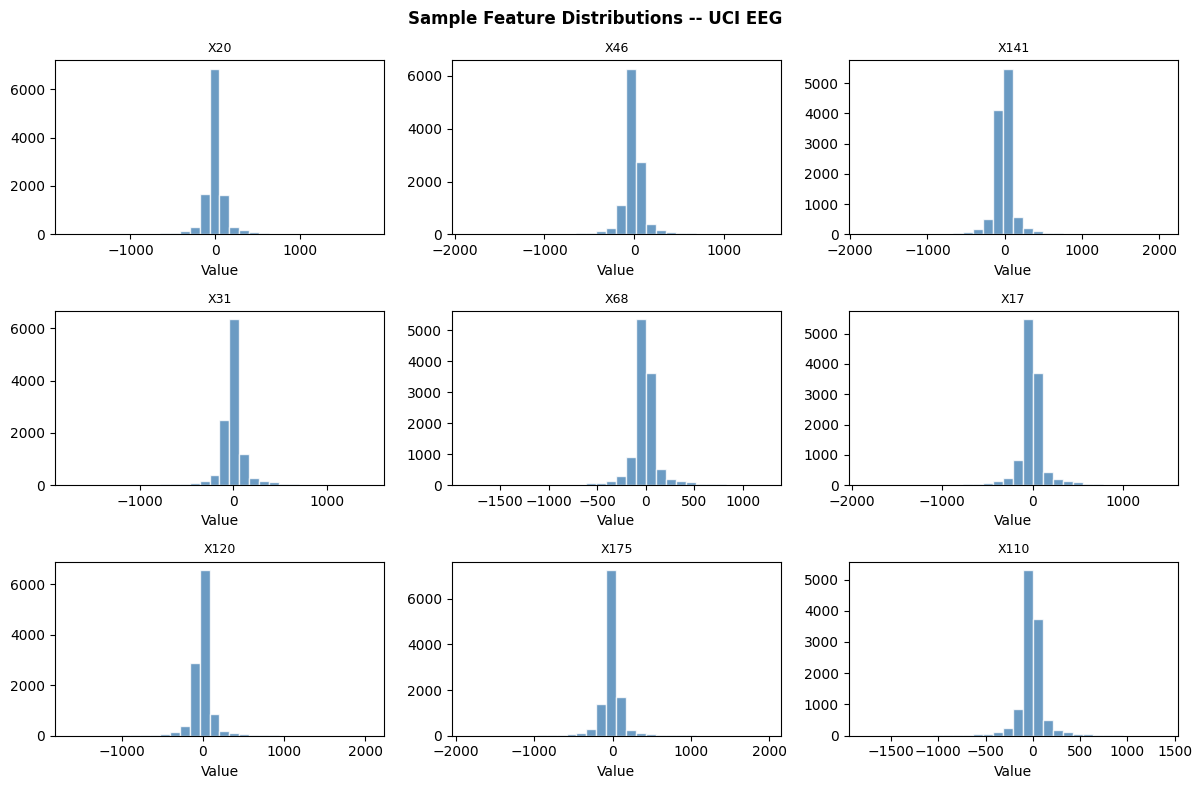

Saved -> outputs\figures\fig1b_feature_distributions.png


In [6]:
if 'UCI_EEG' in data:
    X_uci = data['UCI_EEG']['X']
    sample_cols = X_uci.sample(n=9, axis=1, random_state=SEED).columns
    fig, axes = plt.subplots(3, 3, figsize=(12, 8))
    for ax, col in zip(axes.flatten(), sample_cols):
        ax.hist(X_uci[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
        ax.set_title(col, fontsize=9)
        ax.set_xlabel('Value')
    plt.suptitle('Sample Feature Distributions -- UCI EEG', fontsize=12, fontweight='bold')
    plt.tight_layout()
    save_fig('fig1b_feature_distributions.png')

## Section 2 -- Feature Engineering Functions

In [7]:
def extract_statistical_features(X_array):
    """Time-domain statistical features from raw EEG rows."""
    return pd.DataFrame({
        'mean':  np.mean(X_array,  axis=1),
        'std':   np.std(X_array,   axis=1),
        'var':   np.var(X_array,   axis=1),
        'skew':  skew(X_array,     axis=1),
        'kurt':  kurtosis(X_array, axis=1),
        'rms':   np.sqrt(np.mean(X_array ** 2, axis=1)),
        'zcr':   np.sum(np.diff(np.sign(X_array), axis=1) != 0, axis=1),
        'ptp':   np.ptp(X_array,   axis=1),
    })

def extract_band_power(X_array, fs=178):
    """EEG frequency band power via Welch PSD."""
    bands = {'delta': (0.5, 4), 'theta': (4, 8),
              'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 40)}
    results = {b: [] for b in bands}
    for row in X_array:
        freqs, psd = welch(row, fs=fs, nperseg=min(len(row), 64))
        for band, (lo, hi) in bands.items():
            idx = (freqs >= lo) & (freqs <= hi)
            results[band].append(np.trapezoid(psd[idx], freqs[idx]) if idx.any() else 0.0)
    return pd.DataFrame(results)

def extract_hjorth(X_array):
    """Hjorth Activity, Mobility, Complexity."""
    activity  = np.var(X_array, axis=1)
    d1        = np.diff(X_array, axis=1)
    d2        = np.diff(d1,      axis=1)
    mobility  = np.std(d1, axis=1)  / (np.std(X_array, axis=1) + 1e-10)
    complexity = np.std(d2, axis=1) / (np.std(d1,      axis=1) + 1e-10)
    return pd.DataFrame({'hjorth_activity':    activity,
                          'hjorth_mobility':   mobility,
                          'hjorth_complexity': complexity})

def engineer_features(X_df):
    """Combine statistical + band power + Hjorth into one feature matrix."""
    arr  = X_df.values.astype(float)
    stat = extract_statistical_features(arr)
    band = extract_band_power(arr)
    hjorth = extract_hjorth(arr)
    return pd.concat([stat, band, hjorth], axis=1).reset_index(drop=True)

## Section 3 -- Preprocessing Pipelines

### 3.1 -- Pipeline definitions

In [8]:
def build_pipeline_A():
    """Pipeline A: Raw features -> RobustScaler -> SelectKBest(MI, k=20) -> LR"""
    return Pipeline([
        ('scaler',   RobustScaler()),
        ('selector', SelectKBest(mutual_info_classif, k=20)),
        ('clf',      LogisticRegression(max_iter=1000, random_state=SEED)),
    ], memory=cachedir)

def build_pipeline_B():
    """Pipeline B: Engineered features -> MinMaxScaler -> PCA(95%) -> LR"""
    return Pipeline([
        ('scaler', MinMaxScaler()),
        ('pca',    PCA(n_components=0.95, random_state=SEED)),
        ('clf',    LogisticRegression(max_iter=1000, random_state=SEED)),
    ], memory=cachedir)

### 3.2 -- Evaluate both pipelines on all datasets

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
pipeline_results = []

for name, d in data.items():
    X, y = d['X'], d['y']
    k = min(20, X.shape[1])

    # Pipeline A
    pipe_a = Pipeline([
        ('scaler',   RobustScaler()),
        ('selector', SelectKBest(mutual_info_classif, k=k)),
        ('clf',      LogisticRegression(max_iter=1000, random_state=SEED)),
    ], memory=cachedir)
    scores_a = cross_val_score(pipe_a, X, y, cv=cv,
                               scoring='average_precision', n_jobs=-1)

    # Pipeline B -- engineer features first, then pipe B
    X_eng = engineer_features(X)
    pipe_b = Pipeline([
        ('scaler', MinMaxScaler()),
        ('pca',    PCA(n_components=0.95, random_state=SEED)),
        ('clf',    LogisticRegression(max_iter=1000, random_state=SEED)),
    ], memory=cachedir)
    scores_b = cross_val_score(pipe_b, X_eng, y, cv=cv,
                               scoring='average_precision', n_jobs=-1)

    pipeline_results.append({
        'Dataset':          name,
        'Pipeline_A_mean':  round(scores_a.mean(), 4),
        'Pipeline_A_std':   round(scores_a.std(),  4),
        'Pipeline_B_mean':  round(scores_b.mean(), 4),
        'Pipeline_B_std':   round(scores_b.std(),  4),
        'Winner':           'A' if scores_a.mean() >= scores_b.mean() else 'B',
    })

pipeline_df = pd.DataFrame(pipeline_results)
display(pipeline_df)
pipeline_df.to_csv(os.path.join(RESULTS_DIR, 'pipeline_comparison.csv'), index=False)

,Dataset,Pipeline_A_mean,Pipeline_A_std,Pipeline_B_mean,Pipeline_B_std,Winner
0,UCI_EEG,0.4765,0.0206,0.9539,0.0062,B
1,BEED,0.7655,0.0167,1.0000,0.0000,B
2,Brainwave,0.8287,0.0347,0.8258,0.0128,A


### 3.3 -- Preprocessing order experiment (fig8)

Scale then Select: PR-AUC = 0.4765 +/- 0.0206
Select then Scale: PR-AUC = 0.4725 +/- 0.0186
Extract+Scale+PCA: PR-AUC = 0.9539 +/- 0.0062
Scale+PCA+Select: PR-AUC = 0.4988 +/- 0.0130


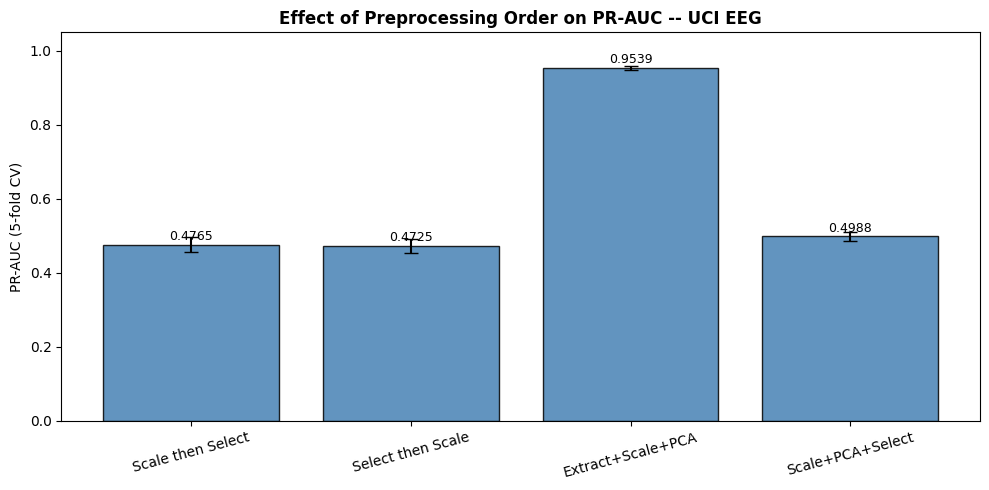

Saved -> outputs\figures\fig8_preprocessing_order.png


In [10]:
if 'UCI_EEG' in data:
    X_uci, y_uci = data['UCI_EEG']['X'], data['UCI_EEG']['y']
    k = min(20, X_uci.shape[1])

    orderings = {
        'Scale then Select':         Pipeline([('sc', RobustScaler()),
                                             ('sel', SelectKBest(mutual_info_classif, k=k)),
                                             ('clf', LogisticRegression(max_iter=1000, random_state=SEED))], memory=cachedir),
        'Select then Scale':         Pipeline([('sel', SelectKBest(mutual_info_classif, k=k)),
                                             ('sc',  RobustScaler()),
                                             ('clf', LogisticRegression(max_iter=1000, random_state=SEED))], memory=cachedir),
        'Extract+Scale+PCA':  None,
        'Scale+PCA+Select':   Pipeline([('sc',  StandardScaler()),
                                             ('pca', PCA(n_components=0.95, random_state=SEED)),
                                             ('sel', SelectKBest(mutual_info_classif, k=k)),
                                             ('clf', LogisticRegression(max_iter=1000, random_state=SEED))], memory=cachedir),
    }

    order_scores = {}

    for label, pipe in orderings.items():
        if label == 'Extract+Scale+PCA':
            X_eng = engineer_features(X_uci)
            pipe_eng = Pipeline([('sc',  MinMaxScaler()),
                                  ('pca', PCA(n_components=0.95, random_state=SEED)),
                                  ('clf', LogisticRegression(max_iter=1000, random_state=SEED))], memory=cachedir)
            sc = cross_val_score(pipe_eng, X_eng, y_uci, cv=cv,
                                 scoring='average_precision', n_jobs=-1)
        else:
            sc = cross_val_score(pipe, X_uci, y_uci, cv=cv,
                                 scoring='average_precision', n_jobs=-1)
        order_scores[label] = sc
        print(f'{label}: PR-AUC = {sc.mean():.4f} +/- {sc.std():.4f}')

    means = [v.mean() for v in order_scores.values()]
    stds  = [v.std()  for v in order_scores.values()]
    labels = list(order_scores.keys())

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(labels, means, yerr=stds, color='steelblue',
                  edgecolor='black', capsize=5, alpha=0.85)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{m:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('PR-AUC (5-fold CV)')
    ax.set_title('Effect of Preprocessing Order on PR-AUC -- UCI EEG', fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    save_fig('fig8_preprocessing_order.png')

### 3.4 -- Scaler comparison

StandardScaler: 0.4784 +/- 0.0163
RobustScaler: 0.4765 +/- 0.0206
MinMaxScaler: 0.4891 +/- 0.0246


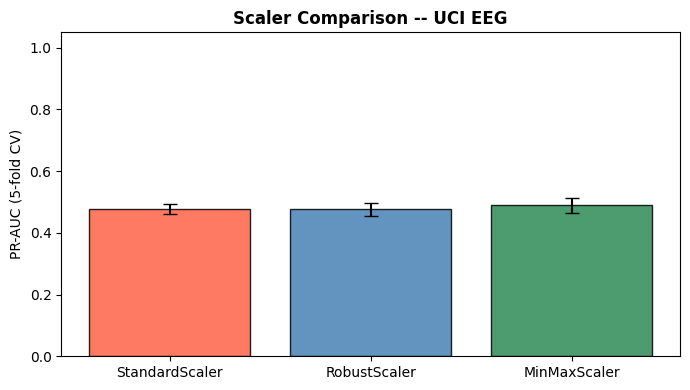

Saved -> outputs\figures\fig8b_scaler_comparison.png


In [11]:
if 'UCI_EEG' in data:
    k = min(20, X_uci.shape[1])
    scalers = {
        'StandardScaler': StandardScaler(),
        'RobustScaler':   RobustScaler(),
        'MinMaxScaler':   MinMaxScaler(),
    }
    scaler_scores = {}
    for sname, scaler in scalers.items():
        pipe = Pipeline([
            ('sc',  scaler),
            ('sel', SelectKBest(mutual_info_classif, k=k)),
            ('clf', LogisticRegression(max_iter=1000, random_state=SEED)),
        ], memory=cachedir)
        sc = cross_val_score(pipe, X_uci, y_uci, cv=cv,
                             scoring='average_precision', n_jobs=-1)
        scaler_scores[sname] = sc
        print(f'{sname}: {sc.mean():.4f} +/- {sc.std():.4f}')

    fig, ax = plt.subplots(figsize=(7, 4))
    means = [v.mean() for v in scaler_scores.values()]
    stds  = [v.std()  for v in scaler_scores.values()]
    ax.bar(list(scaler_scores.keys()), means, yerr=stds,
           color=['tomato', 'steelblue', 'seagreen'],
           edgecolor='black', capsize=5, alpha=0.85)
    ax.set_ylabel('PR-AUC (5-fold CV)')
    ax.set_title('Scaler Comparison -- UCI EEG', fontweight='bold')
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    save_fig('fig8b_scaler_comparison.png')

## Section 4 -- Baseline Model

### 4.1 -- Cross-validated baseline metrics

In [12]:
baseline_results = []

for name, d in data.items():
    X, y = d['X'], d['y']
    k = min(20, X.shape[1])

    pipe = Pipeline([
        ('scaler',   RobustScaler()),
        ('selector', SelectKBest(mutual_info_classif, k=k)),
        ('clf',      LogisticRegression(max_iter=1000, random_state=SEED)),
    ], memory=cachedir)

    cv_result = cross_validate(pipe, X, y, cv=cv,
                               scoring=['accuracy', 'f1', 'average_precision'],
                               return_train_score=False, n_jobs=-1)

    baseline_results.append({
        'Dataset':       name,
        'Accuracy_mean': round(cv_result['test_accuracy'].mean(),          4),
        'Accuracy_std':  round(cv_result['test_accuracy'].std(),           4),
        'F1_mean':       round(cv_result['test_f1'].mean(),                4),
        'F1_std':        round(cv_result['test_f1'].std(),                 4),
        'PR_AUC_mean':   round(cv_result['test_average_precision'].mean(), 4),
        'PR_AUC_std':    round(cv_result['test_average_precision'].std(),  4),
    })
    print(f"[{name}] Accuracy={cv_result['test_accuracy'].mean():.4f}  "
          f"F1={cv_result['test_f1'].mean():.4f}  "
          f"PR-AUC={cv_result['test_average_precision'].mean():.4f}")

baseline_df = pd.DataFrame(baseline_results)
display(baseline_df)
baseline_df.to_csv(os.path.join(RESULTS_DIR, 'baseline_metrics.csv'), index=False)

[UCI_EEG] Accuracy=0.8028  F1=0.0282  PR-AUC=0.4765
[BEED] Accuracy=0.8061  F1=0.8853  PR-AUC=0.7655
[Brainwave] Accuracy=0.9310  F1=0.9046  PR-AUC=0.8287


,Dataset,Accuracy_mean,Accuracy_std,F1_mean,F1_std,PR_AUC_mean,PR_AUC_std
0,UCI_EEG,0.8028,0.0017,0.0282,0.0157,0.4765,0.0206
1,BEED,0.8061,0.0020,0.8853,0.0012,0.7655,0.0167
2,Brainwave,0.9310,0.0075,0.9046,0.0103,0.8287,0.0347


### 4.2 -- Precision-Recall curves (fig2)

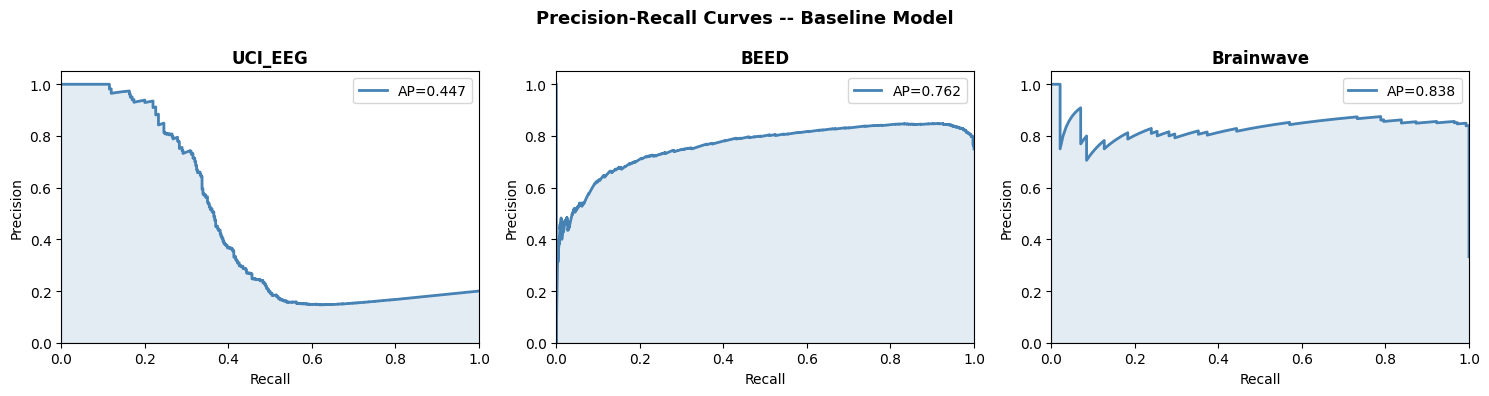

Saved -> outputs\figures\fig2_pr_curves_baseline.png


In [13]:
fig, axes = plt.subplots(1, len(data), figsize=(5 * len(data), 4))
if len(data) == 1:
    axes = [axes]

for ax, (name, d) in zip(axes, data.items()):
    X, y = d['X'], d['y']
    k = min(20, X.shape[1])

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED)

    pipe = Pipeline([
        ('scaler',   RobustScaler()),
        ('selector', SelectKBest(mutual_info_classif, k=k)),
        ('clf',      LogisticRegression(max_iter=1000, random_state=SEED)),
    ], memory=cachedir)
    pipe.fit(X_tr, y_tr)
    scores = pipe.predict_proba(X_te)[:, 1]

    prec, rec, _ = precision_recall_curve(y_te, scores)
    ap = average_precision_score(y_te, scores)

    ax.plot(rec, prec, color='steelblue', lw=2, label=f'AP={ap:.3f}')
    ax.fill_between(rec, prec, alpha=0.15, color='steelblue')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{name}', fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)

plt.suptitle('Precision-Recall Curves -- Baseline Model', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('fig2_pr_curves_baseline.png')

### 4.3 -- Confusion matrices (fig2b)

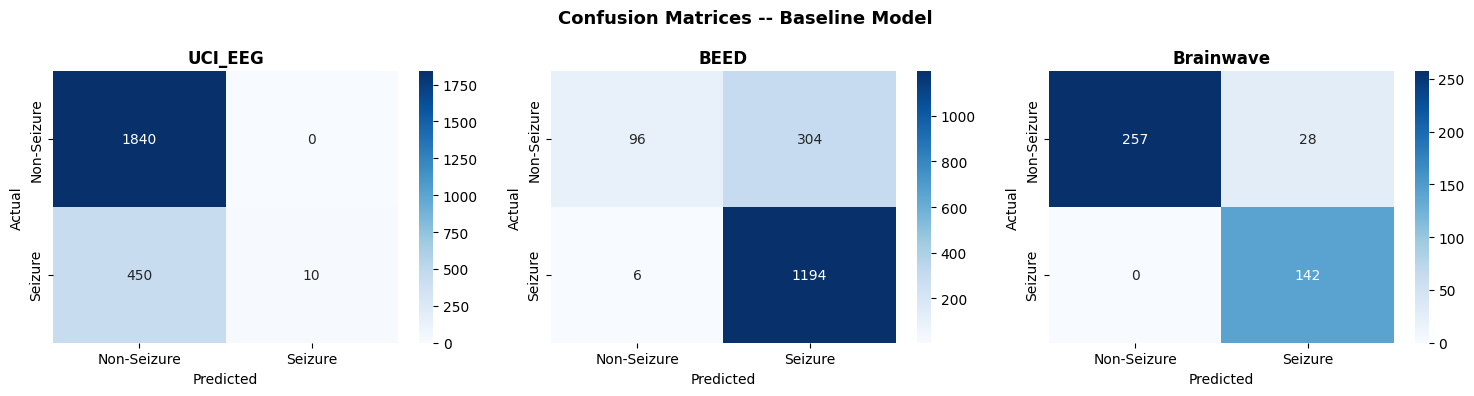

Saved -> outputs\figures\fig2b_confusion_matrices.png


In [14]:
fig, axes = plt.subplots(1, len(data), figsize=(5 * len(data), 4))
if len(data) == 1:
    axes = [axes]

for ax, (name, d) in zip(axes, data.items()):
    X, y = d['X'], d['y']
    k = min(20, X.shape[1])

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED)

    pipe = Pipeline([
        ('scaler',   RobustScaler()),
        ('selector', SelectKBest(mutual_info_classif, k=k)),
        ('clf',      LogisticRegression(max_iter=1000, random_state=SEED)),
    ], memory=cachedir)
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Seizure', 'Seizure'],
                yticklabels=['Non-Seizure', 'Seizure'])
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices -- Baseline Model', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('fig2b_confusion_matrices.png')

## Section 5 -- Overfitting and Underfitting

### 5.1 -- Three model configurations

In [15]:
# Work on UCI_EEG for this section; fall back to first available dataset
primary_name = 'UCI_EEG' if 'UCI_EEG' in data else list(data.keys())[0]
X_p = data[primary_name]['X']
y_p = data[primary_name]['y']
k_p = min(20, X_p.shape[1])

# Pre-transform once for visualization only (noted clearly)
scaler_viz   = RobustScaler()
selector_viz = SelectKBest(mutual_info_classif, k=k_p)
X_transformed = selector_viz.fit_transform(scaler_viz.fit_transform(X_p), y_p)

model_configs = {
    'Underfitting (C=0.0001)': LogisticRegression(C=0.0001, max_iter=1000, random_state=SEED),
    'Good Fit (C=1.0)':        LogisticRegression(C=1.0,    max_iter=1000, random_state=SEED),
    'Overfitting (C=10000)':   LogisticRegression(C=10000,  max_iter=1000, random_state=SEED),
}

### 5.2 -- Train vs validation F1 bar chart (fig3)

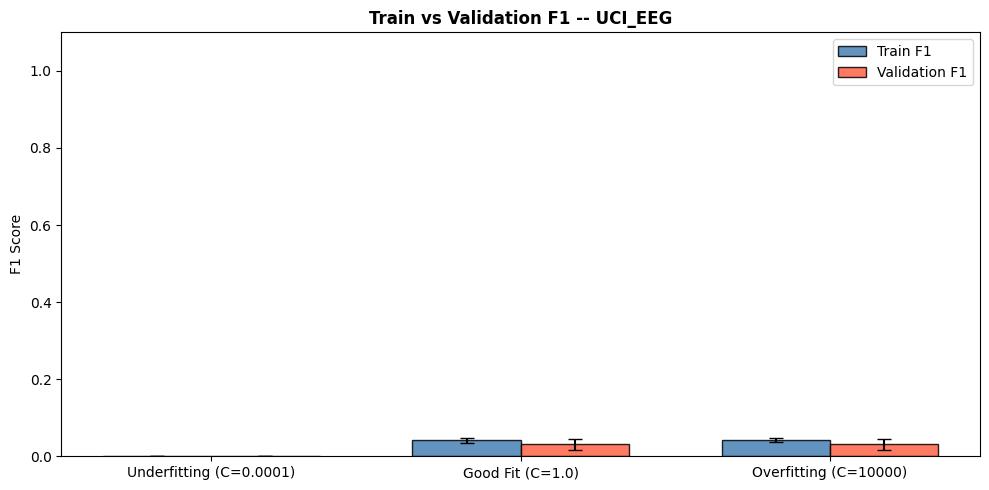

Saved -> outputs\figures\fig3_overfit_underfit.png


In [16]:
overfit_rows = []
for label, clf in model_configs.items():
    cv_res = cross_validate(clf, X_transformed, y_p, cv=cv,
                            scoring='f1', return_train_score=True)
    overfit_rows.append({
        'Config':     label,
        'Train_F1':   cv_res['train_score'].mean(),
        'Val_F1':     cv_res['test_score'].mean(),
        'Train_std':  cv_res['train_score'].std(),
        'Val_std':    cv_res['test_score'].std(),
    })

overfit_df = pd.DataFrame(overfit_rows)

x    = np.arange(len(overfit_df))
w    = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, overfit_df['Train_F1'], w, yerr=overfit_df['Train_std'],
       label='Train F1', color='steelblue', edgecolor='black', capsize=5, alpha=0.85)
ax.bar(x + w/2, overfit_df['Val_F1'],   w, yerr=overfit_df['Val_std'],
       label='Validation F1', color='tomato', edgecolor='black', capsize=5, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(overfit_df['Config'], fontsize=10)
ax.set_ylabel('F1 Score')
ax.set_title(f'Train vs Validation F1 -- {primary_name}', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
save_fig('fig3_overfit_underfit.png')

### 5.3 -- Validation curve: C parameter sweep (fig3b)

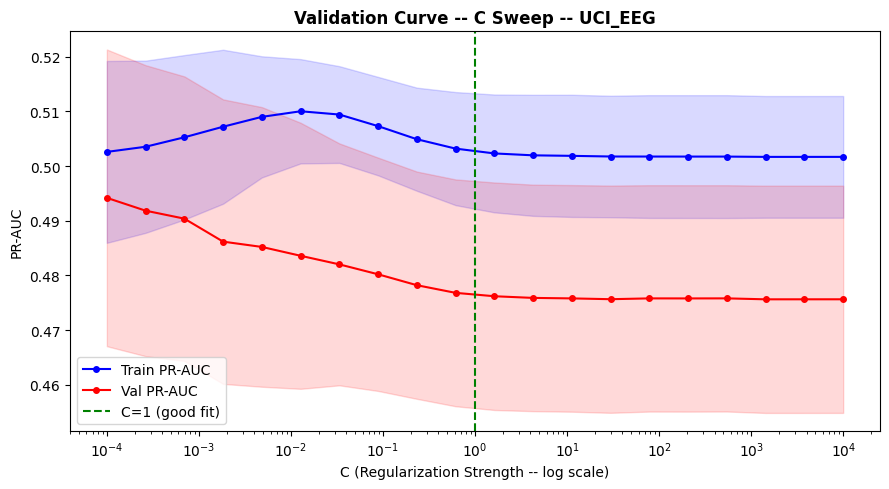

Saved -> outputs\figures\fig3b_validation_curve.png


In [17]:
pipe_vc = Pipeline([
    ('scaler',   RobustScaler()),
    ('selector', SelectKBest(mutual_info_classif, k=k_p)),
    ('clf',      LogisticRegression(max_iter=1000, random_state=SEED)),
], memory=cachedir)
C_range = np.logspace(-4, 4, 20)

train_scores, val_scores = validation_curve(
    pipe_vc, X_p, y_p,
    param_name='clf__C', param_range=C_range,
    cv=cv, scoring='average_precision', n_jobs=-1)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(C_range, train_mean, 'b-o', label='Train PR-AUC',  markersize=4)
ax.fill_between(C_range, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='blue')
ax.semilogx(C_range, val_mean, 'r-o', label='Val PR-AUC', markersize=4)
ax.fill_between(C_range, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='red')
ax.axvline(1.0, color='green', linestyle='--', label='C=1 (good fit)')
ax.set_xlabel('C (Regularization Strength -- log scale)')
ax.set_ylabel('PR-AUC')
ax.set_title(f'Validation Curve -- C Sweep -- {primary_name}', fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig('fig3b_validation_curve.png')

### 5.4 -- Learning curves (fig4)

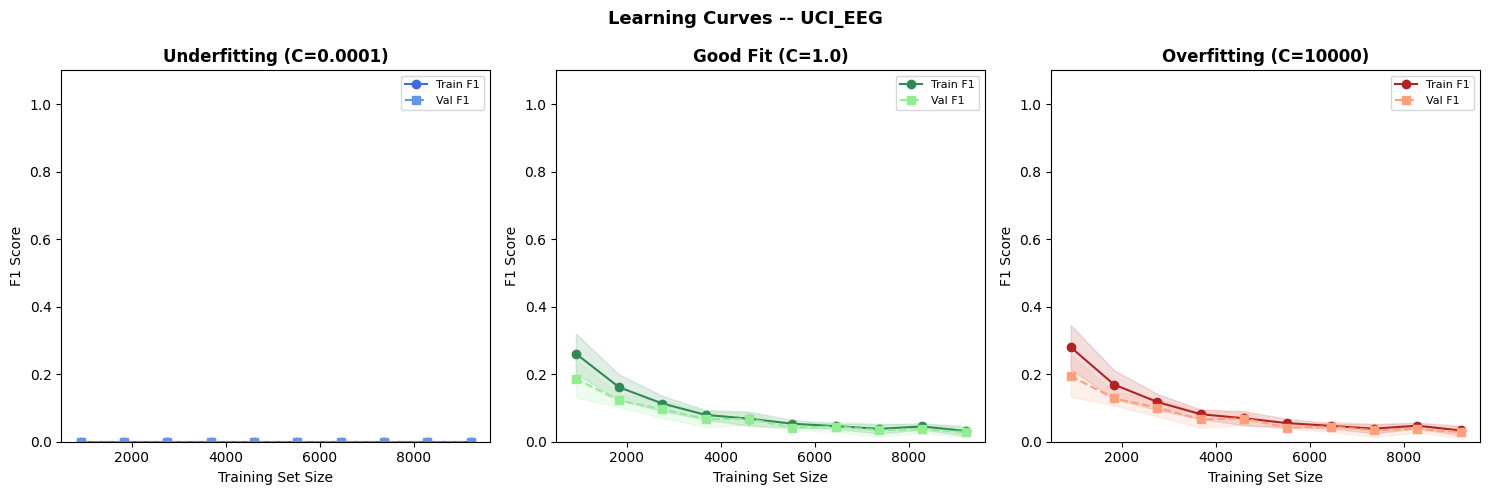

Saved -> outputs\figures\fig4_learning_curves.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = [('royalblue', 'cornflowerblue'),
          ('seagreen',  'lightgreen'),
          ('firebrick', 'lightsalmon')]

for ax, (label, clf), (c_train, c_val) in zip(axes, model_configs.items(), colors):
    pipe_lc = Pipeline([
        ('scaler',   RobustScaler()),
        ('selector', SelectKBest(mutual_info_classif, k=k_p)),
        ('clf',      clf),
    ], memory=cachedir)
    train_sizes, train_sc, val_sc = learning_curve(
        pipe_lc, X_p, y_p,
        cv=cv, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1)

    ax.plot(train_sizes, train_sc.mean(axis=1), 'o-', color=c_train, label='Train F1')
    ax.fill_between(train_sizes,
                    train_sc.mean(axis=1) - train_sc.std(axis=1),
                    train_sc.mean(axis=1) + train_sc.std(axis=1),
                    alpha=0.15, color=c_train)
    ax.plot(train_sizes, val_sc.mean(axis=1), 's--', color=c_val, label='Val F1')
    ax.fill_between(train_sizes,
                    val_sc.mean(axis=1) - val_sc.std(axis=1),
                    val_sc.mean(axis=1) + val_sc.std(axis=1),
                    alpha=0.15, color=c_val)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)

plt.suptitle(f'Learning Curves -- {primary_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('fig4_learning_curves.png')

## Section 6 -- Regularization Study

### 6.1 -- PR-AUC vs C for L1, L2, Elastic Net (fig5)

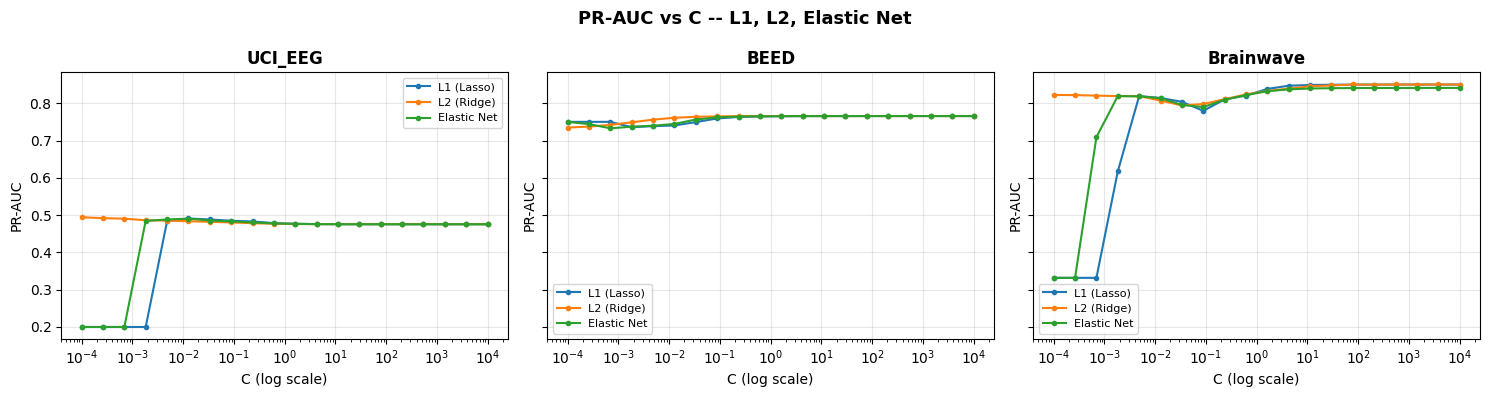

Saved -> outputs\figures\fig5_regularisation_comparison.png


In [19]:
C_values = np.logspace(-4, 4, 20)
regularizers = {
    'L1 (Lasso)':  dict(penalty='l1', solver='liblinear'),
    'L2 (Ridge)':  dict(penalty='l2', solver='lbfgs'),
    'Elastic Net': dict(penalty='elasticnet', solver='saga', l1_ratio=0.5),
}

reg_all_results = []

n_ds = len(data)
fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 4), sharey=True)
if n_ds == 1:
    axes = [axes]

for ax, (name, d) in zip(axes, data.items()):
    X, y = d['X'], d['y']
    k = min(20, X.shape[1])

    for reg_name, reg_params in regularizers.items():
        means, stds = [], []
        for C in C_values:
            pipe = Pipeline([
                ('scaler',   RobustScaler()),
                ('selector', SelectKBest(mutual_info_classif, k=k)),
                ('clf',      LogisticRegression(C=C, max_iter=2000,
                                                random_state=SEED, **reg_params)),
            ], memory=cachedir)
            sc = cross_val_score(pipe, X, y, cv=cv,
                                 scoring='average_precision', n_jobs=-1)
            means.append(sc.mean())
            stds.append(sc.std())

            reg_all_results.append({
                'Dataset':    name,
                'Regularizer': reg_name,
                'C':          C,
                'PR_AUC_mean': sc.mean(),
                'PR_AUC_std':  sc.std(),
            })

        ax.semilogx(C_values, means, 'o-', label=reg_name, markersize=3, lw=1.5)

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('C (log scale)')
    ax.set_ylabel('PR-AUC')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('PR-AUC vs C -- L1, L2, Elastic Net', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('fig5_regularisation_comparison.png')

reg_results_df = pd.DataFrame(reg_all_results)
reg_results_df.to_csv(os.path.join(RESULTS_DIR, 'regularization_results.csv'), index=False)

### 6.2 -- Best C per regularizer per dataset

In [20]:
best_reg = (reg_results_df
            .sort_values('PR_AUC_mean', ascending=False)
            .groupby(['Dataset', 'Regularizer'])
            .first()
            .reset_index()[['Dataset', 'Regularizer', 'C', 'PR_AUC_mean', 'PR_AUC_std']])
best_reg.columns = ['Dataset', 'Regularizer', 'Best_C', 'Best_PR_AUC', 'Std']
display(best_reg)
best_reg.to_csv(os.path.join(RESULTS_DIR, 'best_regularizer_per_dataset.csv'), index=False)

,Dataset,Regularizer,Best_C,Best_PR_AUC,Std
0,BEED,Elastic Net,10000.000000,0.765587,0.016710
1,BEED,L1 (Lasso),10000.000000,0.765589,0.016709
2,BEED,L2 (Ridge),3792.690191,0.765573,0.016733
3,Brainwave,Elastic Net,10000.000000,0.840993,0.024536
4,Brainwave,L1 (Lasso),10000.000000,0.850077,0.020427
5,Brainwave,L2 (Ridge),3792.690191,0.850258,0.020175
6,UCI_EEG,Elastic Net,0.012743,0.490575,0.024817
7,UCI_EEG,L1 (Lasso),0.012743,0.490954,0.023463
8,UCI_EEG,L2 (Ridge),0.000100,0.494194,0.027142


### 6.3 -- Sparsity analysis (fig6)

,Regularizer,Sparsity_%
0,L1 (Lasso),5.0
1,L2 (Ridge),0.0
2,Elastic Net,0.0


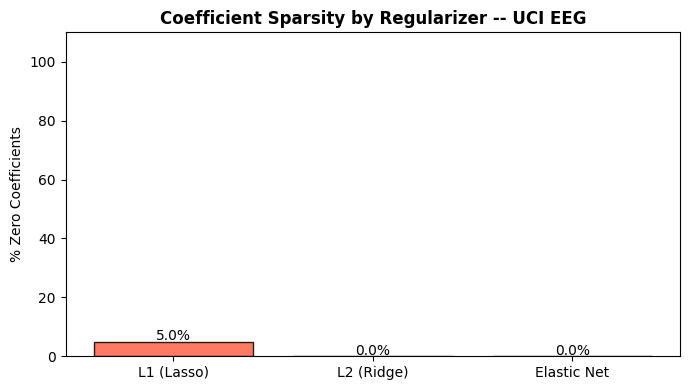

Saved -> outputs\figures\fig6_sparsity.png


In [21]:
if 'UCI_EEG' in data:
    X_uci, y_uci = data['UCI_EEG']['X'], data['UCI_EEG']['y']
    k = min(20, X_uci.shape[1])

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_uci, y_uci, test_size=0.2, stratify=y_uci, random_state=SEED)

    sparsity_rows = []
    coef_dict = {}
    for reg_name, reg_params in regularizers.items():
        pipe = Pipeline([
            ('scaler',   RobustScaler()),
            ('selector', SelectKBest(mutual_info_classif, k=k)),
            ('clf',      LogisticRegression(C=1.0, max_iter=2000,
                                            random_state=SEED, **reg_params)),
        ], memory=cachedir)
        pipe.fit(X_tr, y_tr)
        coefs = pipe.named_steps['clf'].coef_[0]
        coef_dict[reg_name] = coefs
        zero_pct = (np.abs(coefs) < 1e-6).mean() * 100
        sparsity_rows.append({'Regularizer': reg_name, 'Sparsity_%': round(zero_pct, 2)})

    sparsity_df = pd.DataFrame(sparsity_rows)
    display(sparsity_df)
    sparsity_df.to_csv(os.path.join(RESULTS_DIR, 'sparsity_results.csv'), index=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    colors = ['tomato', 'steelblue', 'seagreen']
    ax.bar(sparsity_df['Regularizer'], sparsity_df['Sparsity_%'],
           color=colors, edgecolor='black', alpha=0.85)
    for i, v in enumerate(sparsity_df['Sparsity_%']):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
    ax.set_ylabel('% Zero Coefficients')
    ax.set_title('Coefficient Sparsity by Regularizer -- UCI EEG', fontweight='bold')
    ax.set_ylim(0, 110)
    plt.tight_layout()
    save_fig('fig6_sparsity.png')

### 6.4 -- Regularization stability across datasets (fig5b)

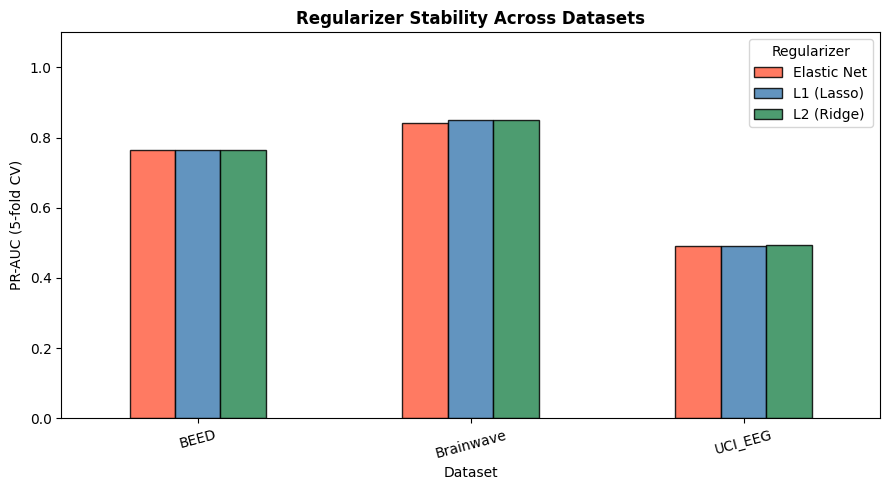

Saved -> outputs\figures\fig5b_regularization_stability.png


In [22]:
stability_rows = []
for name, d in data.items():
    X, y = d['X'], d['y']
    k = min(20, X.shape[1])
    for reg_name, reg_params in regularizers.items():
        mask = (best_reg['Dataset'] == name) & (best_reg['Regularizer'] == reg_name)
        best_c = float(best_reg.loc[mask, 'Best_C'].values[0]) if mask.any() else 1.0

        pipe = Pipeline([
            ('scaler',   RobustScaler()),
            ('selector', SelectKBest(mutual_info_classif, k=k)),
            ('clf',      LogisticRegression(C=best_c, max_iter=2000,
                                            random_state=SEED, **reg_params)),
        ], memory=cachedir)
        sc = cross_val_score(pipe, X, y, cv=cv, scoring='average_precision', n_jobs=-1)
        stability_rows.append({
            'Dataset':     name,
            'Regularizer': reg_name,
            'PR_AUC':      sc.mean(),
            'Std':         sc.std(),
        })

stability_df = pd.DataFrame(stability_rows)
pivot = stability_df.pivot(index='Dataset', columns='Regularizer', values='PR_AUC')

fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.85,
           color=['tomato', 'steelblue', 'seagreen'])
ax.set_ylabel('PR-AUC (5-fold CV)')
ax.set_title('Regularizer Stability Across Datasets', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.set_ylim(0, 1.1)
ax.legend(title='Regularizer')
plt.tight_layout()
save_fig('fig5b_regularization_stability.png')

## Section 7 -- Class Imbalance Handling

### 7.1 -- Build imbalance pipelines

In [23]:
def build_imbalance_pipeline(strategy, k=20):
    """Returns an imblearn Pipeline. Resampling always comes BEFORE scaling."""
    clf = LogisticRegression(max_iter=1000, random_state=SEED)

    if strategy == 'none':
        return ImbPipeline([
            ('scaler',   RobustScaler()),
            ('selector', SelectKBest(mutual_info_classif, k=k)),
            ('clf',      clf),
        ], memory=cachedir)
    elif strategy == 'class_weight':
        return ImbPipeline([
            ('scaler',   RobustScaler()),
            ('selector', SelectKBest(mutual_info_classif, k=k)),
            ('clf',      LogisticRegression(class_weight='balanced',
                                            max_iter=1000, random_state=SEED)),
        ], memory=cachedir)
    elif strategy == 'smote':
        return ImbPipeline([
            ('resample', SMOTE(random_state=SEED)),
            ('scaler',   RobustScaler()),
            ('selector', SelectKBest(mutual_info_classif, k=k)),
            ('clf',      clf),
        ], memory=cachedir)
    elif strategy == 'undersample':
        return ImbPipeline([
            ('resample', RandomUnderSampler(random_state=SEED)),
            ('scaler',   RobustScaler()),
            ('selector', SelectKBest(mutual_info_classif, k=k)),
            ('clf',      clf),
        ], memory=cachedir)
    elif strategy == 'adasyn':
        return ImbPipeline([
            ('resample', ADASYN(random_state=SEED)),
            ('scaler',   RobustScaler()),
            ('selector', SelectKBest(mutual_info_classif, k=k)),
            ('clf',      clf),
        ], memory=cachedir)

### 7.2 -- Evaluate all strategies on all datasets

In [24]:
strategies = ['none', 'class_weight', 'smote', 'undersample', 'adasyn']
imbalance_results = []

for name, d in data.items():
    X, y = d['X'], d['y']
    k = min(20, X.shape[1])

    for strategy in strategies:
        try:
            pipe = build_imbalance_pipeline(strategy, k=k)
            cv_res = cross_validate(pipe, X, y, cv=cv,
                                    scoring=['f1', 'average_precision'],
                                    n_jobs=-1)
            imbalance_results.append({
                'Dataset':       name,
                'Strategy':      strategy,
                'F1_mean':       round(cv_res['test_f1'].mean(),                4),
                'F1_std':        round(cv_res['test_f1'].std(),                 4),
                'PR_AUC_mean':   round(cv_res['test_average_precision'].mean(), 4),
                'PR_AUC_std':    round(cv_res['test_average_precision'].std(),  4),
            })
            print(f"[{name}][{strategy}]  F1={cv_res['test_f1'].mean():.4f}  "
                  f"PR-AUC={cv_res['test_average_precision'].mean():.4f}")
        except Exception as e:
            print(f'[{name}][{strategy}]  SKIPPED: {e}')
            imbalance_results.append({
                'Dataset': name, 'Strategy': strategy,
                'F1_mean': np.nan, 'F1_std': np.nan,
                'PR_AUC_mean': np.nan, 'PR_AUC_std': np.nan,
            })

imbalance_df = pd.DataFrame(imbalance_results)
display(imbalance_df)
imbalance_df.to_csv(os.path.join(RESULTS_DIR, 'imbalance_results.csv'), index=False)

[UCI_EEG][none]  F1=0.0290  PR-AUC=0.4604
[UCI_EEG][class_weight]  F1=0.3415  PR-AUC=0.4513
[UCI_EEG][smote]  F1=0.3313  PR-AUC=0.4534
[UCI_EEG][undersample]  F1=0.3382  PR-AUC=0.4620
[UCI_EEG][adasyn]  F1=0.3100  PR-AUC=0.4334
[BEED][none]  F1=0.8853  PR-AUC=0.7655
[BEED][class_weight]  F1=0.7192  PR-AUC=0.8110
[BEED][smote]  F1=0.7166  PR-AUC=0.8109
[BEED][undersample]  F1=0.7047  PR-AUC=0.8157
[BEED][adasyn]  F1=0.6753  PR-AUC=0.8124
[Brainwave][none]  F1=0.9007  PR-AUC=0.8269
[Brainwave][class_weight]  F1=0.8898  PR-AUC=0.8258
[Brainwave][smote]  F1=0.8818  PR-AUC=0.8283
[Brainwave][undersample]  F1=0.8888  PR-AUC=0.8179
[Brainwave][adasyn]  F1=0.8825  PR-AUC=0.8113


,Dataset,Strategy,F1_mean,F1_std,PR_AUC_mean,PR_AUC_std
0,UCI_EEG,none,0.0290,0.0183,0.4604,0.0131
1,UCI_EEG,class_weight,0.3415,0.0168,0.4513,0.0162
2,UCI_EEG,smote,0.3313,0.0106,0.4534,0.0202
3,UCI_EEG,undersample,0.3382,0.0237,0.4620,0.0399
4,UCI_EEG,adasyn,0.3100,0.0144,0.4334,0.0114
5,BEED,none,0.8853,0.0012,0.7655,0.0167
6,BEED,class_weight,0.7192,0.0136,0.8110,0.0153
7,BEED,smote,0.7166,0.0125,0.8109,0.0169
8,BEED,undersample,0.7047,0.0165,0.8157,0.0146
9,BEED,adasyn,0.6753,0.0171,0.8124,0.0132


### 7.3 -- Precision-Recall curves per strategy (fig7)

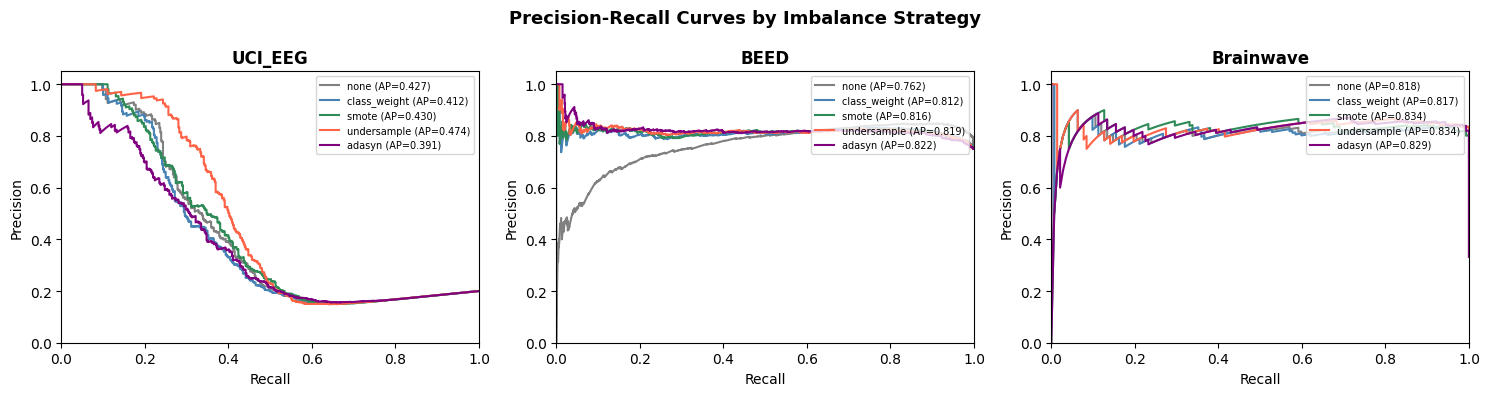

Saved -> outputs\figures\fig7_imbalance_handling.png


In [25]:
n_ds = len(data)
fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 4))
if n_ds == 1:
    axes = [axes]

colors_map = {'none': 'gray', 'class_weight': 'steelblue',
              'smote': 'seagreen', 'undersample': 'tomato', 'adasyn': 'purple'}

for ax, (name, d) in zip(axes, data.items()):
    X, y = d['X'], d['y']
    k = min(20, X.shape[1])

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED)

    for strategy in strategies:
        try:
            pipe = build_imbalance_pipeline(strategy, k=k)
            pipe.fit(X_tr, y_tr)
            scores = pipe.predict_proba(X_te)[:, 1]
            prec, rec, _ = precision_recall_curve(y_te, scores)
            ap = average_precision_score(y_te, scores)
            ax.plot(rec, prec, color=colors_map[strategy], lw=1.5,
                    label=f'{strategy} (AP={ap:.3f})')
        except Exception:
            pass

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)

plt.suptitle('Precision-Recall Curves by Imbalance Strategy', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('fig7_imbalance_handling.png')

### 7.4 -- PR-AUC grouped bar chart (fig7b)

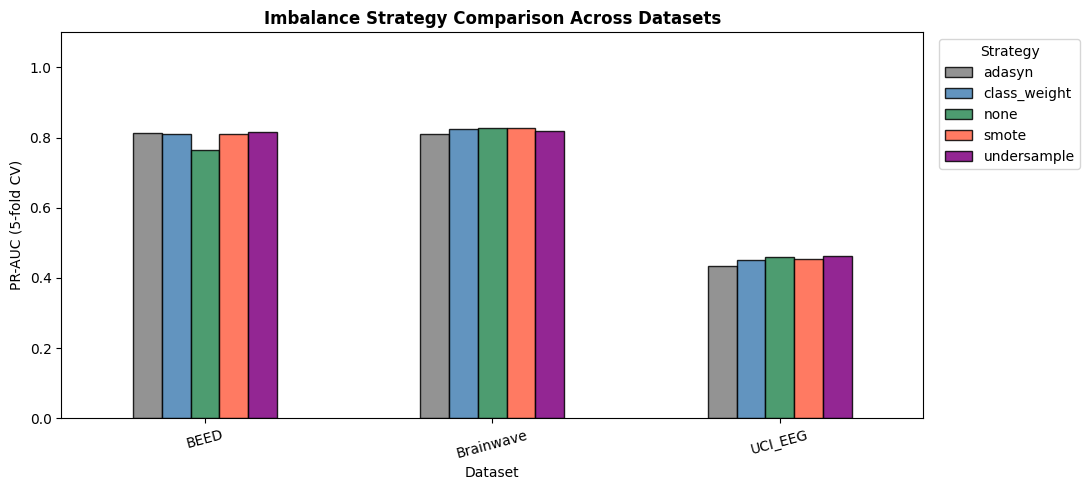

Saved -> outputs\figures\fig7b_imbalance_prauc.png


In [26]:
pivot_imb = imbalance_df.pivot(index='Dataset', columns='Strategy', values='PR_AUC_mean')

fig, ax = plt.subplots(figsize=(11, 5))
pivot_imb.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.85,
               color=list(colors_map.values()))
ax.set_ylabel('PR-AUC (5-fold CV)')
ax.set_title('Imbalance Strategy Comparison Across Datasets', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.set_ylim(0, 1.1)
ax.legend(title='Strategy', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
save_fig('fig7b_imbalance_prauc.png')

## Section 8 -- Comparative Analysis (Research Questions)

### 8.1 -- RQ1: Does preprocessing order affect results?

In [27]:
print('=== RQ1: Preprocessing Order ===')
if 'UCI_EEG' in data:
    for label, sc in order_scores.items():
        print(f'  {label:30s}  PR-AUC = {sc.mean():.4f} +/- {sc.std():.4f}')

    order_df = pd.DataFrame([
        {'Ordering': k, 'PR_AUC_mean': v.mean(), 'PR_AUC_std': v.std()}
        for k, v in order_scores.items()
    ])
    order_df.to_csv(os.path.join(RESULTS_DIR, 'rq1_ordering_results.csv'), index=False)
    best_order = order_df.loc[order_df['PR_AUC_mean'].idxmax(), 'Ordering']
    print(f"\nConclusion: Best ordering = '{best_order}'")
else:
    print('  UCI_EEG not available -- skipping RQ1')

=== RQ1: Preprocessing Order ===
  Scale then Select               PR-AUC = 0.4765 +/- 0.0206
  Select then Scale               PR-AUC = 0.4725 +/- 0.0186
  Extract+Scale+PCA               PR-AUC = 0.9539 +/- 0.0062
  Scale+PCA+Select                PR-AUC = 0.4988 +/- 0.0130

Conclusion: Best ordering = 'Extract+Scale+PCA'


### 8.2 -- RQ2: Which regularization generalizes best?

In [28]:
print('\n=== RQ2: Regularization Generalization ===')
gen_summary = (stability_df.groupby('Regularizer')['PR_AUC']
               .agg(['mean', 'std'])
               .sort_values('mean', ascending=False))
display(gen_summary)
gen_summary.to_csv(os.path.join(RESULTS_DIR, 'rq2_regularizer_generalization.csv'))
best_reg_name = gen_summary.index[0]
print(f"\nConclusion: '{best_reg_name}' achieves highest mean PR-AUC across all datasets.")


=== RQ2: Regularization Generalization ===


,mean,std
Regularizer,,
L2 (Ridge),0.703341,0.186011
L1 (Lasso),0.702206,0.187764
Elastic Net,0.699052,0.184441



Conclusion: 'L2 (Ridge)' achieves highest mean PR-AUC across all datasets.


### 8.3 -- RQ3: Does Elastic Net consistently outperform L1/L2?


=== RQ3: Elastic Net Consistency ===


Regularizer,Elastic Net,L1 (Lasso),L2 (Ridge)
Dataset,,,
BEED,2,1,3
Brainwave,3,2,1
UCI_EEG,3,2,1


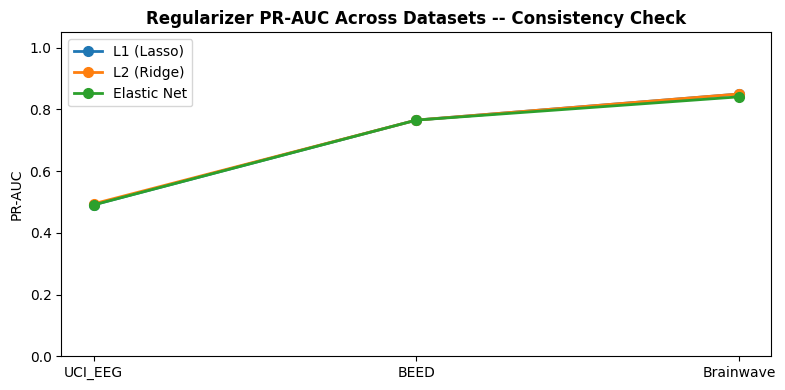

Saved -> outputs\figures\fig5c_elasticnet_consistency.png


In [32]:
print('\n=== RQ3: Elastic Net Consistency ===')
rank_df = stability_df.sort_values(['Dataset', 'PR_AUC'], ascending=[True, False]).copy()
rank_df['Rank'] = rank_df.groupby('Dataset').cumcount() + 1

rank_pivot = rank_df.pivot(index='Dataset', columns='Regularizer', values='Rank')
display(rank_pivot)
rank_pivot.to_csv(os.path.join(RESULTS_DIR, 'rq3_elasticnet_ranks.csv'))

# Line chart across datasets (fig5c)
fig, ax = plt.subplots(figsize=(8, 4))
for reg_name in regularizers:
    subset = stability_df[stability_df['Regularizer'] == reg_name]
    ax.plot(subset['Dataset'], subset['PR_AUC'], 'o-', label=reg_name, lw=2, markersize=7)
ax.set_ylabel('PR-AUC')
ax.set_title('Regularizer PR-AUC Across Datasets -- Consistency Check', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
save_fig('fig5c_elasticnet_consistency.png')

### 8.4 -- RQ4: How does imbalance handling interact with regularization?


=== RQ4: Imbalance x Regularization Interaction ===


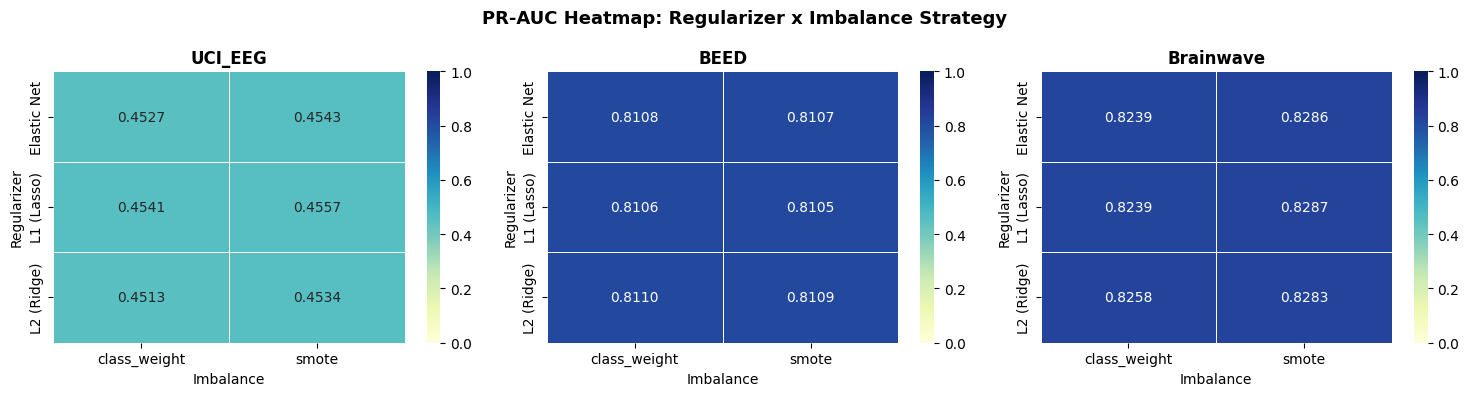

Saved -> outputs\figures\fig9_full_heatmap.png


In [33]:
print('\n=== RQ4: Imbalance x Regularization Interaction ===')

interaction_rows = []
for name, d in data.items():
    X, y = d['X'], d['y']
    k = min(20, X.shape[1])

    for reg_name, reg_params in regularizers.items():
        for strategy in ['class_weight', 'smote']:
            try:
                if strategy == 'class_weight':
                    clf = LogisticRegression(C=1.0, max_iter=2000,
                                             class_weight='balanced',
                                             random_state=SEED, **reg_params)
                    pipe = ImbPipeline([
                        ('scaler',   RobustScaler()),
                        ('selector', SelectKBest(mutual_info_classif, k=k)),
                        ('clf',      clf),
                    ], memory=cachedir)
                else:  # smote
                    pipe = ImbPipeline([
                        ('resample', SMOTE(random_state=SEED)),
                        ('scaler',   RobustScaler()),
                        ('selector', SelectKBest(mutual_info_classif, k=k)),
                        ('clf',      LogisticRegression(C=1.0, max_iter=2000,
                                                        random_state=SEED, **reg_params)),
                    ], memory=cachedir)

                sc = cross_val_score(pipe, X, y, cv=cv,
                                     scoring='average_precision', n_jobs=-1)
                interaction_rows.append({
                    'Dataset':          name,
                    'Regularizer':      reg_name,
                    'Imbalance':        strategy,
                    'PR_AUC_mean':      round(sc.mean(), 4),
                    'PR_AUC_std':       round(sc.std(),  4),
                })
            except Exception as e:
                print(f'  [{name}][{reg_name}][{strategy}] SKIPPED: {e}')
                interaction_rows.append({
                    'Dataset': name, 'Regularizer': reg_name,
                    'Imbalance': strategy,
                    'PR_AUC_mean': np.nan, 'PR_AUC_std': np.nan,
                })

interaction_df = pd.DataFrame(interaction_rows)
interaction_df.to_csv(os.path.join(RESULTS_DIR, 'rq4_interaction_results.csv'), index=False)

# Heatmap per dataset (fig9)
n_ds = len(data)
fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 4))
if n_ds == 1:
    axes = [axes]

for ax, (name, _) in zip(axes, data.items()):
    subset = interaction_df[interaction_df['Dataset'] == name]
    heat = subset.pivot(index='Regularizer', columns='Imbalance', values='PR_AUC_mean')
    sns.heatmap(heat, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
                vmin=0, vmax=1, linewidths=0.5)
    ax.set_title(name, fontweight='bold')

plt.suptitle('PR-AUC Heatmap: Regularizer x Imbalance Strategy', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('fig9_full_heatmap.png')

### 8.5 -- Final summary table

In [34]:
# Best configuration per dataset
summary_rows = []
for name in data.keys():
    # Best pipeline
    pipe_row = pipeline_df[pipeline_df['Dataset'] == name].iloc[0]
    best_pipe = f"Pipeline {pipe_row['Winner']}"
    best_pipe_score = max(pipe_row['Pipeline_A_mean'], pipe_row['Pipeline_B_mean'])

    # Best regularizer
    reg_row = best_reg[best_reg['Dataset'] == name].sort_values('Best_PR_AUC', ascending=False).iloc[0]

    # Best imbalance strategy
    imb_row = imbalance_df[imbalance_df['Dataset'] == name].sort_values('PR_AUC_mean', ascending=False).iloc[0]

    summary_rows.append({
        'Dataset':              name,
        'Best_Pipeline':        best_pipe,
        'Pipeline_PR_AUC':      best_pipe_score,
        'Best_Regularizer':     reg_row['Regularizer'],
        'Regularizer_PR_AUC':   reg_row['Best_PR_AUC'],
        'Best_Imbalance':       imb_row['Strategy'],
        'Imbalance_PR_AUC':     imb_row['PR_AUC_mean'],
    })

final_summary = pd.DataFrame(summary_rows)
display(final_summary)
final_summary.to_csv(os.path.join(RESULTS_DIR, 'final_summary.csv'), index=False)
print('\nAll results saved to outputs/results/')
print('All figures saved to outputs/figures/')

# Clean up temporary pipeline cache
if 'cachedir' in globals() and os.path.exists(cachedir):
    import shutil
    shutil.rmtree(cachedir)
    print('Temporary pipeline cache directory cleaned up.')


,Dataset,Best_Pipeline,Pipeline_PR_AUC,Best_Regularizer,Regularizer_PR_AUC,Best_Imbalance,Imbalance_PR_AUC
0,UCI_EEG,Pipeline B,0.9539,L2 (Ridge),0.494194,undersample,0.4620
1,BEED,Pipeline B,1.0000,L1 (Lasso),0.765589,undersample,0.8157
2,Brainwave,Pipeline A,0.8287,L2 (Ridge),0.850258,smote,0.8283



All results saved to outputs/results/
All figures saved to outputs/figures/
Temporary pipeline cache directory cleaned up.
